<a href="https://colab.research.google.com/github/sanjanav2102/Test-Script-Optimization-and-Duplicate-Analysis-Dashboard/blob/main/Internwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/SCRIPT.DETAILS (2)(SCRIPT.csv",encoding='latin-1')
df.head()

In [ ]:
df.describe()

In [ ]:
df.groupby("SCENARIO.ID")
df.groupby("SCENARIO.ID").size().reset_index(name="count")

In [ ]:
df.groupby("SCRIPT.GROUP")
df.groupby("SCRIPT.GROUP").size().reset_index(name="count")

In [ ]:
df.groupby("OLD.TPR")
df.groupby("OLD.TPR").size().reset_index(name="count")

In [ ]:
df.groupby("APPLICATION")
df.groupby("APPLICATION").size().reset_index(name="count")

In [ ]:
df.groupby("PRODUCT.GROUP")
df.groupby("PRODUCT.GROUP").size().reset_index(name="count")

In [ ]:
# Top Product Groups - Most test happens here
top_products = df['PRODUCT.GROUP'].value_counts().head(10)

top_products.plot(kind='bar')
plt.title("Top 10 Product Groups by Number of Scripts")
plt.xlabel("Product Group")
plt.ylabel("Number of Scripts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Most regression testing is concentrated in RETAIL, BANKING.FRAMEWORK and CORPORATE, indicating these are the most business-critical modules.

In [ ]:
scripts_per_scenario = df.groupby('SCENARIO.ID')['SCRIPT.ID'].count()
scripts_per_scenario.hist(bins=10, range=(1,10))
plt.title("Scripts per Scenario (1 to 10)")
plt.xlabel("Number of Scripts")
plt.ylabel("Frequency")
plt.show()

In [ ]:
scripts_per_scenario.value_counts().head(10)

In [ ]:
#SCRIPT GROUP DISTRIBUTION
top_groups = df['SCRIPT.GROUP'].value_counts().head(10)
top_groups.plot(kind='bar')
plt.title("Top SCRIPT GROUPS")
plt.xlabel("Script Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

TB01-START dominates the regression suite, indicating it is the main testing phase.

In [ ]:
top_apps = df['APPLICATION'].value_counts().head(10)

top_apps.plot(kind='bar')
plt.title("Top 10 Applications Tested")
plt.xlabel("Application")
plt.ylabel("Number of Scripts")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

applications like AA.ACTIVITY and CUSTOMER have higher coverage, showing their importance in banking operations.

In [ ]:
error_counts = df['GENERATE.ERROR'].value_counts()
error_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Error Generation Distribution")
plt.ylabel("")
plt.show()

SCRIPT UPDATED WITH DESCRIPTION

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# import pandas as pd

# df = pd.read_excel("/content/SCRIPT_FINAL.xlsx", dtype=str)

# # Remove empty columns
# df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# # Clean column names
# df.columns = df.columns.str.strip()

# df.head()

In [ ]:
# import pandas as pd
# import os

# df = pd.read_excel("/content/SCRIPT_FINAL.xlsx", dtype=str)

# df.groupby("SCRIPT.GROUP")
# df.groupby("SCRIPT.GROUP").size().reset_index(name="count")



In [ ]:
# # Step 2: Clean data
# df.columns = df.columns.str.strip()
# df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# # Step 3: Create BASE PREFIX (TB01, TB02, etc.)
# df["BASE_GROUP"] = df["SCRIPT.GROUP"].str.split("-").str[0]

# # Step 4: Output folder
# output_path = "grouped_excels"
# os.makedirs(output_path, exist_ok=True)

# # Step 5: Get all unique prefixes
# prefixes = df["BASE_GROUP"].dropna().unique()

# # Step 6: Create separate Excel files
# for prefix in prefixes:
#     group_df = df[df["BASE_GROUP"] == prefix]

#     # Skip empty just in case (safe)
#     if group_df.empty:
#         continue

#     file_path = os.path.join(output_path, f"{prefix}.xlsx")
#     group_df.to_excel(file_path, index=False)

# print("✅ All files created successfully!")

✅ All files created successfully!


In [ ]:
!zip -r folder_download.zip grouped_excels


  adding: grouped_excels/ (stored 0%)
  adding: grouped_excels/XACML01.xlsx (deflated 8%)
  adding: grouped_excels/730435.xlsx (deflated 11%)
  adding: grouped_excels/214.xlsx (deflated 11%)
  adding: grouped_excels/TB08.xlsx (deflated 9%)
  adding: grouped_excels/TB00.xlsx (deflated 1%)
  adding: grouped_excels/BNK.xlsx (deflated 11%)
  adding: grouped_excels/TBO6.xlsx (deflated 11%)
  adding: grouped_excels/TB01.xlsx (deflated 1%)
  adding: grouped_excels/TB06.xlsx (deflated 1%)
  adding: grouped_excels/TB03.xlsx (deflated 1%)
  adding: grouped_excels/XMLOUT04.xlsx (deflated 2%)
  adding: grouped_excels/XMLOUT03.xlsx (deflated 2%)
  adding: grouped_excels/TB05.xlsx (deflated 1%)
  adding: grouped_excels/XMLOUT01.xlsx (deflated 1%)
  adding: grouped_excels/XMLOUT05.xlsx (deflated 2%)
  adding: grouped_excels/TB07.xlsx (deflated 9%)
  adding: grouped_excels/TB02.xlsx (deflated 1%)
  adding: grouped_excels/XMLOUT06.xlsx (deflated 5%)
  adding: grouped_excels/TB04.xlsx (deflated 1%)
  ad

In [ ]:
# from google.colab import files
# files.download("folder_download.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# df.head()

In [ ]:
# # Simple duplicates in the entire dataset
# df[df.duplicated(subset=["DESCRIPTION"], keep=False)]
# # eg creation of customer
# # These are not necessarily exact duplicates in business logic, just same text.

In [ ]:
# #Case-insensitive duplicates
# df["DESC_CLEAN"] = df["DESCRIPTION"].str.lower().str.strip()
# df[df.duplicated(subset=["DESC_CLEAN"], keep=False)]

**ANALYSIS OF TB01_MM.MONEY.MARKET**

In [ ]:
mm01 = pd.read_excel("/content/MM.MONEY.MARKET_TB01.xlsx")
mm01[mm01.duplicated(subset=["TPR.FILE.NAME"], keep=False)]

In [ ]:
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

In [ ]:
# Load the NLP Model
# 'all-MiniLM-L6-v2' is fast, lightweight and excellent for semantic similarity.
print("Loading NLP model...")
model = SentenceTransformer('all-MiniLM-L6-v2')

# Define our similarity threshold (0.0 to 1.0)
# 0.85 is usually a good sweet spot for capturing synonyms without false positives.
THRESHOLD = 0.95

# Add a column to store our duplicate groupings
mm01['DUPLICATE_GROUP'] = None
group_counter = 1

# 4. Group by TPR.FILE.NAME to enforce the exact match rule
grouped = mm01.groupby('TPR.FILE.NAME')

for tpr_name, group in grouped:
    # If there's only 1 item in this TPR group, it can't have duplicates
    if len(group) < 2:
        continue

    # Get the descriptions and their original indices
    indices = group.index.tolist()
    descriptions = group['DESCRIPTION'].fillna("").tolist()

    # Convert text to vectors
    embeddings = model.encode(descriptions)

    # Calculate similarity between all descriptions in this specific TPR group
    sim_matrix = cosine_similarity(embeddings)

    # Track which items have been assigned to a duplicate group
    assigned = set()

    for i in range(len(indices)):
        if i in assigned:
            continue

        # Find all descriptions similar to item 'i' (including itself)
        # np.where returns the indices where the similarity is > THRESHOLD
        similar_items = np.where(sim_matrix[i] > THRESHOLD)[0]

        # If we found actual duplicates (more than just the item matching itself)
        if len(similar_items) > 1:
            for j in similar_items:
                mm01.at[indices[j], 'DUPLICATE_GROUP'] = f"Group_{group_counter}"
                assigned.add(j)
            group_counter += 1

# 5. Filter and review the results
duplicates_only = mm01[mm01['DUPLICATE_GROUP'].notnull()]
duplicates_sorted = duplicates_only.sort_values(by=['DUPLICATE_GROUP', 'TPR.FILE.NAME'])

print("Found", len(duplicates_sorted), "potential duplicate scripts.")
# duplicates_sorted.to_csv('flagged_duplicates.csv', index=False)

Loading NLP model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Found 576 potential duplicate scripts.


In [ ]:
duplicates_sorted

In [ ]:
import pandas as pd

def export_clustered_table(df, output_filename='duplicate_scripts_report.csv'):
    duplicates_sorted.to_csv(output_filename, index=False)
    print(f"Report generated: {output_filename}")
export_clustered_table(duplicates_sorted)

Report generated: duplicate_scripts_report.csv


Increase the threshold for better redundency check

In [ ]:
mm01_up = pd.read_excel("/content/MM.MONEY.MARKET_TB01.xlsx")
mm01_up[mm01_up.duplicated(subset=["TPR.FILE.NAME"], keep=False)]
# Load the NLP Model
# 'all-MiniLM-L6-v2' is fast, lightweight and excellent for semantic similarity.
print("Loading NLP model...")
model = SentenceTransformer('all-MiniLM-L6-v2')

# Define our similarity threshold (0.0 to 1.0)
# 0.85 is usually a good sweet spot for capturing synonyms without false positives.
THRESHOLD = 0.98

# Add a column to store our duplicate groupings
mm01_up['DUPLICATE_GROUP'] = None
group_counter = 1

# 4. Group by TPR.FILE.NAME to enforce the exact match rule
grouped = mm01_up.groupby('TPR.FILE.NAME')

for tpr_name, group in grouped:
    # If there's only 1 item in this TPR group, it can't have duplicates
    if len(group) < 2:
        continue

    # Get the descriptions and their original indices
    indices = group.index.tolist()
    descriptions = group['DESCRIPTION'].fillna("").tolist()

    # Convert text to vectors
    embeddings = model.encode(descriptions)

    # Calculate similarity between all descriptions in this specific TPR group
    sim_matrix = cosine_similarity(embeddings)

    # Track which items have been assigned to a duplicate group
    assigned = set()

    for i in range(len(indices)):
        if i in assigned:
            continue

        # Find all descriptions similar to item 'i' (including itself)
        # np.where returns the indices where the similarity is > THRESHOLD
        similar_items = np.where(sim_matrix[i] > THRESHOLD)[0]

        # If we found actual duplicates (more than just the item matching itself)
        if len(similar_items) > 1:
            for j in similar_items:
                mm01_up.at[indices[j], 'DUPLICATE_GROUP'] = f"Group_{group_counter}"
                assigned.add(j)
            group_counter += 1

# 5. Filter and review the results
duplicates_only = mm01_up[mm01_up['DUPLICATE_GROUP'].notnull()]
duplicates_sorted_up = duplicates_only.sort_values(by=['DUPLICATE_GROUP', 'TPR.FILE.NAME'])

print("Found", len(duplicates_sorted), "potential duplicate scripts.")
# duplicates_sorted.to_csv('flagged_duplicates.csv', index=False)

Loading NLP model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Found 576 potential duplicate scripts.


In [ ]:
duplicates_sorted_up

In [ ]:
import pandas as pd

def export_clustered_table(df, output_filename='duplicate_scripts_report_updated.csv'):
    duplicates_sorted_up.to_csv(output_filename, index=False)
    print(f"Report generated: {output_filename}")
export_clustered_table(duplicates_sorted_up)

Report generated: duplicate_scripts_report_updated.csv


ADDED A BUSINESS LOGIC

In [ ]:
import pandas as pd
import numpy as np
import re
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Load Data
mm01_up = pd.read_excel("/content/MM.MONEY.MARKET_TB01.xlsx")

print("Loading NLP model...")
model = SentenceTransformer('all-MiniLM-L6-v2')

THRESHOLD = 0.95 # You can lower this back to 0.95 now that we have the strict veto rules

# 2. Define the Business Veto Rules
def contains_clashing_keywords(desc1, desc2):
    """
    Returns True if the descriptions contain mutually exclusive banking terms.
    """
    d1 = str(desc1).lower()
    d2 = str(desc2).lower()

    # Rule A: Exact Scenario Number clash (e.g., Scenario 1 vs Scenario 2)
    scen1 = re.findall(r'scenario \d+', d1)
    scen2 = re.findall(r'scenario \d+', d2)
    if scen1 and scen2 and scen1[0] != scen2[0]:
        return True

    # Rule B: Mutually Exclusive Banking Terms
    exclusive_lists = [
        ['loan', 'deposit'],
        ['accrual param as first', 'accrual param as last', 'accrual param as both', 'without accrual param'],
        ['positive spread', 'negative spread']
    ]

    for excl_list in exclusive_lists:
        # Check which keywords from the list are in each description
        found_in_1 = [kw for kw in excl_list if kw in d1]
        found_in_2 = [kw for kw in excl_list if kw in d2]

        # If both descriptions have a keyword from this category,
        # but they don't share the exact SAME keyword, they clash!
        if found_in_1 and found_in_2 and not set(found_in_1).intersection(set(found_in_2)):
            return True

    return False

# Add a column to store our duplicate groupings
mm01_up['DUPLICATE_GROUP'] = None
group_counter = 1

# 3. Process Groupings
grouped = mm01_up.groupby('TPR.FILE.NAME')

for tpr_name, group in grouped:
    if len(group) < 2:
        continue

    indices = group.index.tolist()
    descriptions = group['DESCRIPTION'].fillna("").tolist()
    embeddings = model.encode(descriptions)
    sim_matrix = cosine_similarity(embeddings)
    assigned = set()

    for i in range(len(indices)):
        if i in assigned:
            continue

        similar_items = np.where(sim_matrix[i] > THRESHOLD)[0]

        # New Step: Filter similar items through our Business Rules
        valid_duplicates = [i] # It always matches itself

        for j in similar_items:
            if i != j and j not in assigned:
                if not contains_clashing_keywords(descriptions[i], descriptions[j]):
                    valid_duplicates.append(j)

        # Apply grouping only if valid duplicates exist
        if len(valid_duplicates) > 1:
            for j in valid_duplicates:
                mm01_up.at[indices[j], 'DUPLICATE_GROUP'] = f"Group_{group_counter}"
                assigned.add(j)
            group_counter += 1

# 4. Review the Duplicates
duplicates_only = mm01_up[mm01_up['DUPLICATE_GROUP'].notnull()]
duplicates_sorted_up = duplicates_only.sort_values(by=['DUPLICATE_GROUP', 'TPR.FILE.NAME'])
print("Found", len(duplicates_sorted_up), "potential duplicate scripts.")

# ---------------------------------------------------------
# NEW REQUIREMENT: Generate a file of all UNIQUE test scripts
# ---------------------------------------------------------

# A. Grab all scripts that were NEVER assigned to a duplicate group
unique_standalone = mm01_up[mm01_up['DUPLICATE_GROUP'].isnull()]

# B. Grab exactly ONE representative script from each Duplicate Group
unique_from_groups = mm01_up[mm01_up['DUPLICATE_GROUP'].notnull()].drop_duplicates(subset=['DUPLICATE_GROUP'])

# C. Combine them to create the master unique list
all_unique_scripts = pd.concat([unique_standalone, unique_from_groups])

# D. Export to a clean Excel file
all_unique_scripts.to_excel("All_Unique_Scripts.xlsx", index=False)
print("Saved unique test script master list to All_Unique_Scripts.xlsx")

Loading NLP model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Found 543 potential duplicate scripts.
Saved unique test script master list to All_Unique_Scripts.xlsx


In [ ]:
duplicates_sorted_up

In [ ]:
import pandas as pd

def export_clustered_table(df, output_filename='duplicate_scripts_bl.csv'):
    duplicates_sorted_up.to_csv(output_filename, index=False)
    print(f"Report generated: {output_filename}")
export_clustered_table(duplicates_sorted_up)

Report generated: duplicate_scripts_bl.csv


ANALYSIS - II

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
scripts = pd.read_excel("/content/SCRIPT_FINAL.xlsx",dtype=str)
# Remove empty columns
scripts = scripts.loc[:, ~scripts.columns.str.contains('^Unnamed')]
# Clean column names
scripts.columns = scripts.columns.str.strip()


mmtb01 = pd.read_excel("/content/MM.MONEY.MARKET_TB01.xlsx")


In [ ]:
scripts.head()

In [ ]:
scripts.shape

(622669, 12)

In [ ]:
mmtb01.head()

In [ ]:
# Joined mmtb01 with scripts based on scenario id present in mmtb01
# The scenario id is sorted, and the order of exectution is also correct based on tpr.file.name
# EDGE CASE: SCRPT06023051195

import pandas as pd

# Merge
result_df = pd.merge(
    mmtb01[['SCENARIO.ID']],
    scripts[['SCENARIO.ID', 'SCRIPT.ID', 'DESCRIPTION', 'FUNCTION', 'APPLICATION', 'TPR.FILE.NAME']],
    on='SCENARIO.ID',
    how='inner'
).drop_duplicates()
# Extract numeric order from TPR.FILE.NAME
result_df['TPR_ORDER'] = result_df['TPR.FILE.NAME'].str.extract(r'(\d+)').astype(int)
#Sort by SCENARIO.ID and TPR order
result_df = result_df.sort_values(by=['SCENARIO.ID', 'TPR_ORDER'])
# Drop helper column
#result_df = result_df.drop(columns=['TPR_ORDER']).reset_index(drop=True)

result_df

In [ ]:
# How many unique scenarios are present in TB01 mm01 with varied applications
result_df['SCENARIO.ID'].value_counts()

In [ ]:
# Realising the edge case in the delimited dataframe - SCRPT06023051195

# Extract script number
result_df['SCRIPT_NO'] = result_df['SCRIPT.ID'].str.extract(r'-(\d+)$')
# Group and concatenate
final_df = result_df.groupby('SCENARIO.ID').agg({
    'SCRIPT_NO': lambda x: '|'.join(x),
    'DESCRIPTION': lambda x: '|'.join(x),
    'FUNCTION': lambda x: '|'.join(x),
    'APPLICATION': lambda x: '|'.join(x)
}).reset_index()
# Rename columns
final_df.columns = ['SCENARIO.ID', 'SCRIPT.ID', 'DESCRIPTION', 'FUNCTION', 'APPLICATION']
#Step 5: Print as TAB delimited
#print(final_df.to_csv(sep='\t', index=False))
final_df

In [ ]:
# EDGE CASE RECTIFIED - sorted using tpr first, if same tpr next priority to script id
# check : SCRPT06023051195
import pandas as pd

# Merge
result_new_df = pd.merge(
    mmtb01[['SCENARIO.ID']],
    scripts[['SCENARIO.ID', 'SCRIPT.ID', 'DESCRIPTION', 'FUNCTION', 'APPLICATION', 'TPR.FILE.NAME']],
    on='SCENARIO.ID',
    how='inner'
).drop_duplicates()

# Extract TPR order
result_new_df['TPR_ORDER'] = result_new_df['TPR.FILE.NAME'].str.extract(r'(\d+)').astype(int)
# NEW: Extract script order (001, 002, ...)
result_new_df['SCRIPT_ORDER'] = result_new_df['SCRIPT.ID'].str.extract(r'-(\d+)$').astype(int)
# sort using BOTH
result_new_df = result_new_df.sort_values(
    by=['SCENARIO.ID', 'TPR_ORDER', 'SCRIPT_ORDER']
)

# Reset index
result_new_df = result_new_df.reset_index(drop=True)
result_new_df


FINAL DELIMITED FILE FOR CONTEXT BUILDING

In [ ]:
# SY.ACCU.DECU with SCRIPT_FINAL
# Extract script number
syaccu = pd.read_csv("/content/SY.ACCU.DECU_allgroup.xlsx")
result_new_df['SCRIPT_NO'] = result_new_df['SCRIPT.ID'].str.extract(r'-(\d+)$')
# Group and concatenate
final_new_df = result_new_df.groupby('SCENARIO.ID').agg({
    'SCRIPT_NO': lambda x: '|'.join(x),
    'DESCRIPTION': lambda x: '|'.join(x),
    'FUNCTION': lambda x: '|'.join(x),
    'APPLICATION': lambda x: '|'.join(x)
}).reset_index()
# Rename columns
final_new_df.columns = ['SCENARIO.ID', 'SCRIPT.ID', 'DESCRIPTION', 'FUNCTION', 'APPLICATION']
#Step 5: Print as TAB delimited
#print(final_df.to_csv(sep='\t', index=False))
final_new_df

GEMINI API

In [ ]:
# #update to new model
# !pip install -U google-generativeai

In [ ]:
# # Setup and API Configuration
# !pip install -q -U google-generativeai sentence-transformers

# import google.generativeai as genai
# import pandas as pd
# from google.colab import userdata

# # Setup Gemini API
# # Make sure to add your API key to Colab Secrets (the key icon on the left)
# genai.configure(api_key=userdata.get('contextbuildingapikey'))
# # UPDATE THIS LINE:
# model = genai.GenerativeModel(model_name='gemini-3-flash-preview')

In [ ]:
# try:
#     # Testing with the 2026 current model
#     test_model = genai.GenerativeModel('gemini-3-flash-preview')
#     response = test_model.generate_content("Ping")
#     print("Connection Successful: ", response.text)
# except Exception as e:
#     print(f"Connection Failed. The error is: {e}")

Connection Failed. The error is: 404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-3-flash is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.


In [ ]:
# #Generate the Context Paragraphs
# #We will define a function to clean the pipe-delimited (|) descriptions and ask the
# #AI to synthesize them into a single coherent scenario context.

# def generate_context(description_text):
#     # Clean up the pipe-delimited text for the prompt
#     parts = description_text.replace('|', '\n- ')

#     prompt = f"""
#     Below are fragmented descriptions for a banking software test scenario.
#     Synthesize them into one concise, professional context paragraph (max 3 sentences).
#     Focus on the transaction type, customer action, and specific financial parameters.

#     Descriptions:
#     {parts}
#     """

#     try:
#         response = model.generate_content(prompt)
#         return response.text.strip()
#     except Exception as e:
#         return "Error generating context"

# # Apply the function to create a new column
# # Note: For large datasets, use time.sleep(1) to respect rate limits
# final_new_df['Generated_Context'] = final_new_df['DESCRIPTION'].apply(generate_context)

In [ ]:
# final_new_df

In [ ]:
# # 1. Install the Excel engine (usually pre-installed in Colab, but good to ensure)
# !pip install -q openpyxl

# import pandas as pd
# from google.colab import files

# # 2. Define your filename
# filename = 'Banking_Scenario_Analysis.xlsx'

# # 3. Convert the DataFrame to Excel
# # we use index=False so the row numbers aren't saved as a separate column
# final_new_df.to_excel(filename, index=False, engine='openpyxl')

# # 4. Trigger the download to your local computer
# files.download(filename)

In [ ]:
# '''Find Semantic Duplicates
# Standard string matching often fails because "Fixed maturity" and "Maturity is fixed" are
# the same thing to a human but different to a computer. We use embeddings to calculate similarity scores.'''
# from sentence_transformers import SentenceTransformer, util
# import torch

# # Load a pre-trained model for semantic similarity
# embed_model = SentenceTransformer('all-MiniLM-L6-v2')

# # Encode the generated contexts
# contexts = final_new_df['Generated_Context'].tolist()
# embeddings = embed_model.encode(contexts, convert_to_tensor=True)

# # Compute cosine similarity between all pairs
# cosine_scores = util.cos_sim(embeddings, embeddings)

# # Identify pairs with high similarity (e.g., > 0.90)
# duplicates = []
# for i in range(len(cosine_scores)):
#     for j in range(i + 1, len(cosine_scores)):
#         if cosine_scores[i][j] > 0.90:
#             duplicates.append({
#                 'ID_1': final_new_df.iloc[i]['SCENARIO.ID'],
#                 'ID_2': final_new_df.iloc[j]['SCENARIO.ID'],
#                 'Similarity': cosine_scores[i][j].item(),
#                 'Context_1': contexts[i],
#                 'Context_2': contexts[j]
#             })

# duplicates_df = pd.DataFrame(duplicates)

GROQ AI

In [ ]:
# !pip install -q groq

# from groq import Groq
# from google.colab import userdata
# import time

# # Initialize Groq Client
# client = Groq(api_key=userdata.get('GROQ_API_KEY'))

# def generate_context_groq(description_text):
#     if not description_text or pd.isna(description_text):
#         return None

#     prompt = f"Synthesize these banking test fragments into one professional paragraph:\n{description_text}"

#     try:
#         # Using Llama 3 8B for extreme speed and high free limits
#         chat_completion = client.chat.completions.create(
#             messages=[{"role": "user", "content": prompt}],
#             model="llama-3.1-8b-instant",
#         )
#         return chat_completion.choices[0].message.content
#     except Exception as e:
#         # If you hit a rate limit (30 requests/min), wait a bit
#         if "429" in str(e):
#             time.sleep(10)
#             return generate_context_groq(description_text)
#         return None

# # Process 1000 rows (This will take ~5-10 minutes)
# print("Starting context generation on Groq...")
# final_new_df['Generated_Context'] = final_new_df['DESCRIPTION'].apply(generate_context_groq)
# print("Done!")

ANALYSIS WITH SY.ACCU.DECU

In [ ]:
# EDGE CASE RECTIFIED - sorted using tpr first, if same tpr next priority to script id
# check : SCRPT06023051195
import pandas as pd
syacc = pd.read_excel("/content/SY.ACCU.DECU_allgroup.xlsx")
# Merge
result_new_df= pd.merge(
    syacc[['SCENARIO.ID']],
    scripts[['SCENARIO.ID', 'SCRIPT.ID', 'DESCRIPTION', 'FUNCTION', 'APPLICATION', 'TPR.FILE.NAME']],
    on='SCENARIO.ID',
    how='inner'
).drop_duplicates()

# Extract TPR order
result_new_df['TPR_ORDER'] = result_new_df['TPR.FILE.NAME'].str.extract(r'(\d+)').astype(int)
# NEW: Extract script order (001, 002, ...)
result_new_df['SCRIPT_ORDER'] = result_new_df['SCRIPT.ID'].str.extract(r'-(\d+)$').astype(int)
# sort using BOTH
result_new_df = result_new_df.sort_values(
    by=['SCENARIO.ID', 'TPR_ORDER', 'SCRIPT_ORDER']
)

# Reset index
result_new_df= result_new_df.reset_index(drop=True)
result_new_df


In [ ]:
# SY.ACCU.DECU with SCRIPT_FINAL
# Extract script number
syaccu = pd.read_excel("/content/SY.ACCU.DECU_allgroup.xlsx")
result_new_df['SCRIPT_NO'] = result_new_df['SCRIPT.ID'].str.extract(r'-(\d+)$')
# Group and concatenate
final_new_df = result_new_df.groupby('SCENARIO.ID').agg({
    'SCRIPT_NO': lambda x: '|'.join(x),
    'DESCRIPTION': lambda x: '|'.join(x),
    'FUNCTION': lambda x: '|'.join(x),
    'APPLICATION': lambda x: '|'.join(x)
}).reset_index()
# Rename columns
final_new_df.columns = ['SCENARIO.ID', 'SCRIPT.ID', 'DESCRIPTION', 'FUNCTION', 'APPLICATION']
#Step 5: Print as TAB delimited
#print(final_df.to_csv(sep='\t', index=False))
final_new_df

In [ ]:
# 1. Install the Excel engine (usually pre-installed in Colab, but good to ensure)
!pip install -q openpyxl

import pandas as pd
from google.colab import files

# 2. Define your filename
filename = 'SY.ACC_delimited.xlsx'

# 3. Convert the DataFrame to Excel
# we use index=False so the row numbers aren't saved as a separate column
final_new_df.to_excel(filename, index=False, engine='openpyxl')

# 4. Trigger the download to your local computer
files.download(filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
scripts = pd.read_excel("/content/SCRIPT_FINAL.xlsx",dtype=str)
# Remove empty columns
scripts = scripts.loc[:, ~scripts.columns.str.contains('^Unnamed')]
# Clean column names
scripts.columns = scripts.columns.str.strip()
scripts.head()

In [ ]:
scripts.groupby("SCENARIO.ID")
scripts.groupby("SCENARIO.ID").size().reset_index(name="count")

,SCENARIO.ID,count
0,10336703-214,1
1,125,1
2,SCRPT016192080004,1
3,SCRPT016192080100,2
4,SCRPT03070714999,2
...,...,...
98010,SCRPT339010344910,4
98011,SCRPT339010344911,9
98012,SCRPT710611222021,6
98013,record with future processing date along with ...,1


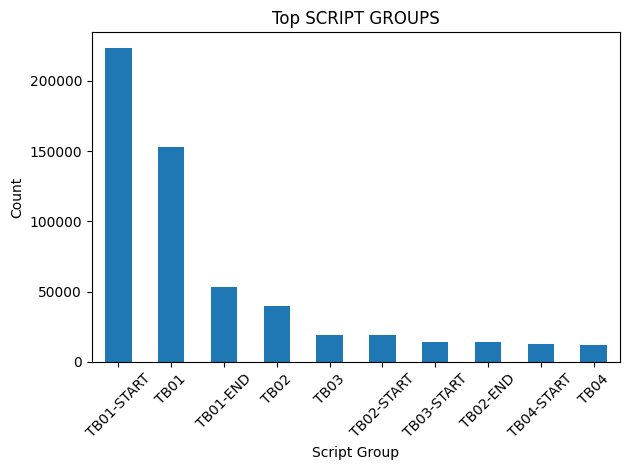

In [ ]:
#SCRIPT GROUP DISTRIBUTION
top_groups = scripts['SCRIPT.GROUP'].value_counts().head(10)
top_groups.plot(kind='bar')
plt.title("Top SCRIPT GROUPS")
plt.xlabel("Script Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

ANALYSIS - III

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("/content/SCRIPT.csv", dtype="str", encoding='latin-1')
# Remove empty columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
# Clean column names
df.columns = df.columns.str.strip()
df.head()

In [ ]:
# data cleaning
df['RF.FILE.NAME'] = df['RF.FILE.NAME'].str.replace('ü', ',', regex=False)
df.head()

In [ ]:
import pandas as pd
# DOWNLOAD CLEANED/REPLACED u WITH ,
def export_clustered_table(df, output_filename='cleaned_script3.csv'):
    df.to_csv(output_filename, index=False)
    print(f"Report generated: {output_filename}")
export_clustered_table(df)

Report generated: cleaned_script3.csv


In [ ]:
# Creation of the delimited file for the above
# EDGE CASE RECTIFIED - sorted using tpr first, if same tpr next priority to script id
# check : SCRPT06023051195
import pandas as pd
rf_mm_tb01= pd.read_excel("/content/cleaned_rf_TB01_MM.xlsx")
# Merge
result_new_df= pd.merge(
    rf_mm_tb01[['SCENARIO.ID']],
    df[['SCENARIO.ID', 'SCRIPT.ID', 'DESCRIPTION', 'FUNCTION', 'APPLICATION', 'TPR.FILE.NAME','RF.FILE.NAME']],
    on='SCENARIO.ID',
    how='inner'
).drop_duplicates()

# Extract TPR order
result_new_df['TPR_ORDER'] = result_new_df['TPR.FILE.NAME'].str.extract(r'(\d+)').astype(int)
# NEW: Extract script order (001, 002, ...)
result_new_df['SCRIPT_ORDER'] = result_new_df['SCRIPT.ID'].str.extract(r'-(\d+)$').astype(int)
# sort using BOTH
result_new_df = result_new_df.sort_values(
    by=['SCENARIO.ID', 'TPR_ORDER', 'SCRIPT_ORDER']
)

# Reset index
result_new_df= result_new_df.reset_index(drop=True)
result_new_df['SCENARIO.ID'].nunique()


985

In [ ]:
# Lets use ! to delimit various rf.file names of the same scenario
# rf_tb01_mm with SCRIPT_FINAL
# Extract script number
# Extract script number
result_new_df['SCRIPT_NO'] = result_new_df['SCRIPT.ID'].str.extract(r'-(\d+)$')

# Fill NaN and convert to string
cols = ['SCRIPT_NO', 'DESCRIPTION', 'FUNCTION', 'APPLICATION', 'RF.FILE.NAME']
result_new_df[cols] = result_new_df[cols].fillna('').astype(str)

# Group and concatenate (order preserved)
final_new_df = result_new_df.groupby('SCENARIO.ID', sort=False).agg({
    'SCRIPT_NO': lambda x: '|'.join(x),
    'DESCRIPTION': lambda x: '|'.join(x),
    'FUNCTION': lambda x: '|'.join(x),
    'APPLICATION': lambda x: '|'.join(x),
    'RF.FILE.NAME': lambda x: '!'.join(x)
}).reset_index()

# Rename columns
final_new_df.columns = ['SCENARIO.ID', 'SCRIPT.ID', 'DESCRIPTION', 'FUNCTION', 'APPLICATION', 'RF.FILE.NAME']

final_new_df

In [ ]:
import pandas as pd
# DOWNLOAD CLEANED/REPLACED u WITH ,
def export_clustered_table(df, output_filename='delimited_rf_mm_tb01.csv'):
    final_new_df.to_csv(output_filename, index=False)
    print(f"Report generated: {output_filename}")
export_clustered_table(final_new_df)

Report generated: delimited_rf_mm_tb01.csv


ANALYSIS WITH THE APPLICATION FOREX AND TB01

In [ ]:
import pandas as pd
forex_tb01= pd.read_excel("/content/Tb01_forex.xlsx")
# Merge
result_new_df= pd.merge(
    forex_tb01[['SCENARIO.ID']],
    df[['SCENARIO.ID', 'SCRIPT.ID', 'DESCRIPTION', 'FUNCTION', 'APPLICATION', 'TPR.FILE.NAME','RF.FILE.NAME']],
    on='SCENARIO.ID',
    how='inner'
).drop_duplicates()

# Extract TPR order
result_new_df['TPR_ORDER'] = result_new_df['TPR.FILE.NAME'].str.extract(r'(\d+)').astype(int)
# NEW: Extract script order (001, 002, ...)
result_new_df['SCRIPT_ORDER'] = result_new_df['SCRIPT.ID'].str.extract(r'-(\d+)$').astype(int)
# sort using BOTH
result_new_df = result_new_df.sort_values(
    by=['SCENARIO.ID', 'TPR_ORDER', 'SCRIPT_ORDER']
)

# Reset index
result_new_df= result_new_df.reset_index(drop=True)
result_new_df

In [ ]:
# Lets use ! to delimit various rf.file names of the same scenario
# rf_tb01_mm with SCRIPT_FINAL
# Extract script number
# Extract script number
result_new_df['SCRIPT_NO'] = result_new_df['SCRIPT.ID'].str.extract(r'-(\d+)$')

# Fill NaN and convert to string
cols = ['SCRIPT_NO', 'DESCRIPTION', 'FUNCTION', 'APPLICATION', 'RF.FILE.NAME']
result_new_df[cols] = result_new_df[cols].fillna('').astype(str)

# Group and concatenate (order preserved)
final_new_df = result_new_df.groupby('SCENARIO.ID', sort=False).agg({
    'SCRIPT_NO': lambda x: '|'.join(x),
    'DESCRIPTION': lambda x: '|'.join(x),
    'FUNCTION': lambda x: '|'.join(x),
    'APPLICATION': lambda x: '|'.join(x),
    'RF.FILE.NAME': lambda x: '!'.join(x)
}).reset_index()

# Rename columns
final_new_df.columns = ['SCENARIO.ID', 'SCRIPT.ID', 'DESCRIPTION', 'FUNCTION', 'APPLICATION', 'RF.FILE.NAME']

final_new_df

In [ ]:
import pandas as pd
# DOWNLOAD CLEANED/REPLACED u WITH ,
def export_clustered_table(df, output_filename='delimited_forex_tb01.csv'):
    final_new_df.to_csv(output_filename, index=False)
    print(f"Report generated: {output_filename}")
export_clustered_table(final_new_df)

Report generated: delimited_forex_tb01.csv


Analysis Final

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("/content/SCRIPT.csv", dtype="str", encoding='latin-1')
# Remove empty columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
# Clean column names
df.columns = df.columns.str.strip()
df.head()

In [ ]:
rf_mm_tb01= pd.read_excel("/content/cleaned_rf_TB01_MM.xlsx")
rf_mm_tb01['SCENARIO.ID'].nunique()

989

In [ ]:
# =========================================================
# STEP 1 — LOAD DATA
# =========================================================

import pandas as pd
import re

rf_mm_tb01 = pd.read_excel("/content/cleaned_rf_TB01_MM.xlsx")

# df = MAIN SCRIPT FILE
# Must contain:
# SCENARIO.ID
# SCRIPT.ID
# SCRIPT.GROUP
# DESCRIPTION
# FUNCTION
# APPLICATION
# PRODUCT.GROUP
# TPR.FILE.NAME
# RF.FILE.NAME

# =========================================================
# STEP 2 — MERGE
# =========================================================

result_new_df = pd.merge(
    rf_mm_tb01[['SCENARIO.ID']],
    df[
        [
            'SCENARIO.ID',
            'SCRIPT.ID',
            'SCRIPT.GROUP',
            'DESCRIPTION',
            'FUNCTION',
            'APPLICATION',
            'PRODUCT.GROUP',
            'TPR.FILE.NAME',
            'RF.FILE.NAME'
        ]
    ],
    on='SCENARIO.ID',
    how='inner'
).drop_duplicates()

# =========================================================
# STEP 3 — EXTRACT SORTING HELPERS
# =========================================================

# Extract numeric TPR order
result_new_df['TPR_ORDER'] = (
    result_new_df['TPR.FILE.NAME']
    .str.extract(r'(\d+)')
    .astype(int)
)

# Extract script sequence (001,002...)
result_new_df['SCRIPT_ORDER'] = (
    result_new_df['SCRIPT.ID']
    .str.extract(r'-(\d+)$')
    .astype(int)
)

# =========================================================
# STEP 4 — SCRIPT GROUP PRIORITY
# =========================================================

# Priority:
# TBxx-START -> first
# TBxx       -> second
# TBxx-END   -> third
# others     -> last

def get_group_priority(group):

    if pd.isna(group):
        return (999, 999)

    group = str(group).upper()

    # Extract TB number
    match = re.search(r'TB(\d+)', group)

    tb_num = int(match.group(1)) if match else 999

    # Determine phase
    if '-START' in group:
        phase = 1
    elif '-END' in group:
        phase = 3
    elif re.fullmatch(r'TB\d+', group):
        phase = 2
    else:
        phase = 4

    return (tb_num, phase)

# Create helper columns
result_new_df[['TB_NUM', 'TB_PHASE']] = (
    result_new_df['SCRIPT.GROUP']
    .apply(get_group_priority)
    .apply(pd.Series)
)

# =========================================================
# STEP 5 — FINAL SORTING
# =========================================================

result_new_df = result_new_df.sort_values(
    by=[
        'SCENARIO.ID',
        'TB_NUM',
        'TB_PHASE',
        'TPR_ORDER',
        'SCRIPT_ORDER'
    ]
)

result_new_df = result_new_df.reset_index(drop=True)

# =========================================================
# STEP 6 — EXTRACT SCRIPT NUMBER
# =========================================================

result_new_df['SCRIPT_NO'] = (
    result_new_df['SCRIPT.ID']
    .str.extract(r'-(\d+)$')
)

# =========================================================
# STEP 7 — CLEAN NULLS
# =========================================================

cols = [
    'SCRIPT_NO',
    'SCRIPT.GROUP',
    'DESCRIPTION',
    'FUNCTION',
    'APPLICATION',
    'PRODUCT.GROUP',
    'RF.FILE.NAME'
]

result_new_df[cols] = (
    result_new_df[cols]
    .fillna('')
    .astype(str)
)

# =========================================================
# STEP 8 — CREATE DELIMITED FILE
# =========================================================

final_new_df = (
    result_new_df
    .groupby('SCENARIO.ID', sort=False)
    .agg({

        'SCRIPT_NO': lambda x: '|'.join(x),

        'SCRIPT.GROUP': lambda x: '|'.join(x),

        'DESCRIPTION': lambda x: '|'.join(x),

        'FUNCTION': lambda x: '|'.join(x),

        'APPLICATION': lambda x: '|'.join(x),

        'PRODUCT.GROUP': lambda x: '|'.join(x),

        'RF.FILE.NAME': lambda x: '!'.join(x)

    })
    .reset_index()
)

# =========================================================
# STEP 9 — RENAME COLUMNS
# =========================================================

final_new_df.columns = [
    'SCENARIO.ID',
    'SCRIPT.ID',
    'SCRIPT.GROUP',
    'DESCRIPTION',
    'FUNCTION',
    'APPLICATION',
    'PRODUCT.GROUP',
    'RF.FILE.NAME'
]

# =========================================================
# STEP 10 — EXPORT
# =========================================================

output_filename = 'delimited_mm_tb01.csv'

final_new_df.to_csv(output_filename, index=False)

print(f"Report generated: {output_filename}")

# Preview
final_new_df.shape

Report generated: delimited_mm_tb01.csv


(989, 8)

In [ ]:
# =========================================================
# FIND SCENARIO IDs WHERE SCRIPT ORDER IS INCORRECT
# =========================================================

def is_sorted_script_sequence(script_string):

    # Example:
    # "001|002|003|005|004"

    try:
        nums = [int(x) for x in script_string.split('|') if x.strip() != '']

        return nums == sorted(nums)

    except:
        return False


# Find unsorted rows
unsorted_df = final_new_df[
    ~final_new_df['SCRIPT.ID'].apply(is_sorted_script_sequence)
]

# Print scenario ids
print("Scenario IDs with UNSORTED script sequence:\n")

#for scenario_id in unsorted_df['SCENARIO.ID']:
    #print(scenario_id)

# Optional preview
unsorted_df[['SCENARIO.ID', 'SCRIPT.ID']]

ANALYSIS USING FOREX GROUP

In [ ]:
forex_tb01= pd.read_excel("/content/Tb01_forex.xlsx")
forex_tb01['SCENARIO.ID'].nunique()

845

In [ ]:
# =========================================================
# STEP 1 — LOAD DATA
# =========================================================

import pandas as pd
import re

forex_tb01= pd.read_excel("/content/Tb01_forex.xlsx")

# df = MAIN SCRIPT FILE
# Must contain:
# SCENARIO.ID
# SCRIPT.ID
# SCRIPT.GROUP
# DESCRIPTION
# FUNCTION
# APPLICATION
# PRODUCT.GROUP
# TPR.FILE.NAME
# RF.FILE.NAME

# =========================================================
# STEP 2 — MERGE
# =========================================================

result_new_df = pd.merge(
   forex_tb01[['SCENARIO.ID']],
    df[
        [
            'SCENARIO.ID',
            'SCRIPT.ID',
            'SCRIPT.GROUP',
            'DESCRIPTION',
            'FUNCTION',
            'APPLICATION',
            'PRODUCT.GROUP',
            'TPR.FILE.NAME',
            'RF.FILE.NAME'
        ]
    ],
    on='SCENARIO.ID',
    how='inner'
).drop_duplicates()

# =========================================================
# STEP 3 — EXTRACT SORTING HELPERS
# =========================================================

# Extract numeric TPR order
result_new_df['TPR_ORDER'] = (
    result_new_df['TPR.FILE.NAME']
    .str.extract(r'(\d+)')
    .astype(int)
)

# Extract script sequence (001,002...)
result_new_df['SCRIPT_ORDER'] = (
    result_new_df['SCRIPT.ID']
    .str.extract(r'-(\d+)$')
    .astype(int)
)

# =========================================================
# STEP 4 — SCRIPT GROUP PRIORITY
# =========================================================

# Priority:
# TBxx-START -> first
# TBxx       -> second
# TBxx-END   -> third
# others     -> last

def get_group_priority(group):

    if pd.isna(group):
        return (999, 999)

    group = str(group).upper()

    # Extract TB number
    match = re.search(r'TB(\d+)', group)

    tb_num = int(match.group(1)) if match else 999

    # Determine phase
    if '-START' in group:
        phase = 1
    elif '-END' in group:
        phase = 3
    elif re.fullmatch(r'TB\d+', group):
        phase = 2
    else:
        phase = 4

    return (tb_num, phase)

# Create helper columns
result_new_df[['TB_NUM', 'TB_PHASE']] = (
    result_new_df['SCRIPT.GROUP']
    .apply(get_group_priority)
    .apply(pd.Series)
)

# =========================================================
# STEP 5 — FINAL SORTING
# =========================================================

result_new_df = result_new_df.sort_values(
    by=[
        'SCENARIO.ID',
        'TB_NUM',
        'TB_PHASE',
        'TPR_ORDER',
        'SCRIPT_ORDER'
    ]
)

result_new_df = result_new_df.reset_index(drop=True)

# =========================================================
# STEP 6 — EXTRACT SCRIPT NUMBER
# =========================================================

result_new_df['SCRIPT_NO'] = (
    result_new_df['SCRIPT.ID']
    .str.extract(r'-(\d+)$')
)

# =========================================================
# STEP 7 — CLEAN NULLS
# =========================================================

cols = [
    'SCRIPT_NO',
    'SCRIPT.GROUP',
    'DESCRIPTION',
    'FUNCTION',
    'APPLICATION',
    'PRODUCT.GROUP',
    'RF.FILE.NAME'
]

result_new_df[cols] = (
    result_new_df[cols]
    .fillna('')
    .astype(str)
)

# =========================================================
# STEP 8 — CREATE DELIMITED FILE
# =========================================================

final_new_df = (
    result_new_df
    .groupby('SCENARIO.ID', sort=False)
    .agg({

        'SCRIPT_NO': lambda x: '|'.join(x),

        'SCRIPT.GROUP': lambda x: '|'.join(x),

        'DESCRIPTION': lambda x: '|'.join(x),

        'FUNCTION': lambda x: '|'.join(x),

        'APPLICATION': lambda x: '|'.join(x),

        'PRODUCT.GROUP': lambda x: '|'.join(x),

        'RF.FILE.NAME': lambda x: '!'.join(x)

    })
    .reset_index()
)

# =========================================================
# STEP 9 — RENAME COLUMNS
# =========================================================

final_new_df.columns = [
    'SCENARIO.ID',
    'SCRIPT.ID',
    'SCRIPT.GROUP',
    'DESCRIPTION',
    'FUNCTION',
    'APPLICATION',
    'PRODUCT.GROUP',
    'RF.FILE.NAME'
]

# =========================================================
# STEP 10 — EXPORT
# =========================================================

output_filename = 'delimited_forex_tb01_new.csv'

final_new_df.to_csv(output_filename, index=False)

print(f"Report generated: {output_filename}")

# Preview
final_new_df.shape

Report generated: delimited_forex_tb01_new.csv


(845, 8)

In [ ]:
df.shape

(623461, 13)